# Multi-class Text Classification Experiment - Experimenting with Different Methods

This notebook will build on the work done in the binary sentiment analysis notebook that experimented with different methods of separating text into 2 categories. Instead this time we will do multi-class classification instead of binary classification. Our data will come from Kaggle and be on news article topics. You can find the dataset [here on Kaggle.](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset?select=test.csv)

In [68]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
import torch

In [69]:
train_df = pd.read_csv('train.csv') 
val_df = pd.read_csv('test.csv') 
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [70]:
# Saving the mapping of class indices to class names for later use
class_map = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

We see each dataset contains 3 columns, we will concatenate the title to the description.

In [71]:
train_df["text"] = train_df["Title"] + " - " + train_df["Description"]
val_df["text"] = val_df["Title"] + " - " + val_df["Description"]
train_df = train_df.rename(columns={'Class Index': 'label'})
val_df = val_df.rename(columns={'Class Index': 'label'})

train_df = train_df[["text", "label"]]
val_df = val_df[["text", "label"]]


In [72]:
train_df.shape

(120000, 2)

In [73]:
train_df["label"].value_counts()

label
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

In [74]:
val_df.shape

(7600, 2)

In [75]:
val_df["label"].value_counts()

label
3    1900
4    1900
2    1900
1    1900
Name: count, dtype: int64

We see the the classes are balanced, so no need to sample.

Lastly we will encode the pos/neg labels as numeric values and we will apply some text cleaning to standardize text. 

In [76]:
train_df

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,3
1,Carlyle Looks Toward Commercial Aerospace (Reu...,3
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,3
3,Iraq Halts Oil Exports from Main Southern Pipe...,3
4,"Oil prices soar to all-time record, posing new...",3
...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,1
119996,Renteria signing a top-shelf deal - Red Sox ge...,2
119997,Saban not going to Dolphins yet - The Miami Do...,2
119998,Today's NFL games - PITTSBURGH at NY GIANTS Ti...,2


In [77]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['text_clean'] = train_df['text'].apply(clean_text)
val_df['text_clean'] = val_df['text'].apply(clean_text)

## Method 1: Bag of Words with Decision Tree
The most primitive way to turn our text into numeric features to use for prediction would be to use a "bag of words" approach where each word in the text becomes a column value and we count the number of times it appears in the sequence. 

In [78]:
y_train = train_df['label']
y_val = val_df['label']

In [79]:
%%time
vectorizer = CountVectorizer(stop_words='english', min_df=2)

X_train = vectorizer.fit_transform(train_df['text_clean'])
X_val = vectorizer.transform(val_df['text_clean'])
bow_model = DecisionTreeClassifier(max_depth=10, random_state=42)
bow_model.fit(X_train, y_train)


CPU times: user 1.61 s, sys: 48.1 ms, total: 1.65 s
Wall time: 1.73 s


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [80]:
%%time
y_pred = bow_model.predict(X_val)

CPU times: user 853 μs, sys: 753 μs, total: 1.61 ms
Wall time: 2.14 ms


In [81]:
print('Validation classification report:')
print(classification_report(y_val, y_pred))

Validation classification report:
              precision    recall  f1-score   support

           1       0.88      0.38      0.53      1900
           2       0.93      0.27      0.42      1900
           3       0.88      0.18      0.31      1900
           4       0.32      0.97      0.48      1900

    accuracy                           0.45      7600
   macro avg       0.75      0.45      0.43      7600
weighted avg       0.75      0.45      0.43      7600



Text(0.5, 1.0, 'BOW Model Accuracy Score: 0.45092105263157894')

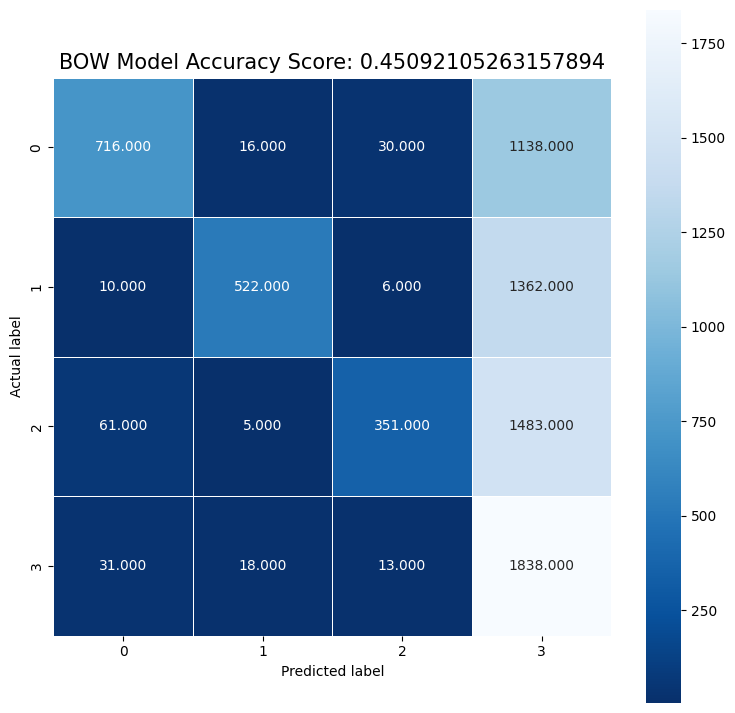

In [82]:
conf_matrix = confusion_matrix(y_val, y_pred)
acc = bow_model.score(X_val, y_val)
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'BOW Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

Results show that using Bag-of-words features can be a viable way to give a model enough content to be intelligent, but there are ways to increase the quality of context we can provide to a model.

## Method 2: TF-IDF Vectorizer + Decision Tree
The Bag of Words approach is maybe our most simple method of capturing vocabulary, but we can improve on this. TF-IDF allows our model to understand the importance of terms that show up throughout a dataset. We will see how increasing the complexity of feature collection will affect the accuracy of prediction with the same Decision Tree model. 

In [83]:
%%time
tfidf = TfidfVectorizer(stop_words='english', min_df=2)
X_train_tfidf = tfidf.fit_transform(train_df['text_clean'])
X_val_tfidf = tfidf.transform(val_df['text_clean'])

tfidf_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tfidf_model.fit(X_train_tfidf, y_train)

CPU times: user 2.72 s, sys: 48.4 ms, total: 2.77 s
Wall time: 2.83 s


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [84]:
%%time
y_pred_tfidf = tfidf_model.predict(X_val_tfidf)

CPU times: user 1.03 ms, sys: 1.04 ms, total: 2.07 ms
Wall time: 2.42 ms


In [85]:
print('TF-IDF Validation classification report:')
print(classification_report(y_val, y_pred_tfidf))

TF-IDF Validation classification report:
              precision    recall  f1-score   support

           1       0.88      0.38      0.53      1900
           2       0.93      0.28      0.42      1900
           3       0.86      0.18      0.30      1900
           4       0.31      0.96      0.47      1900

    accuracy                           0.45      7600
   macro avg       0.75      0.45      0.43      7600
weighted avg       0.75      0.45      0.43      7600



Text(0.5, 1.0, 'TF-IDF Model Accuracy Score: 0.44973684210526316')

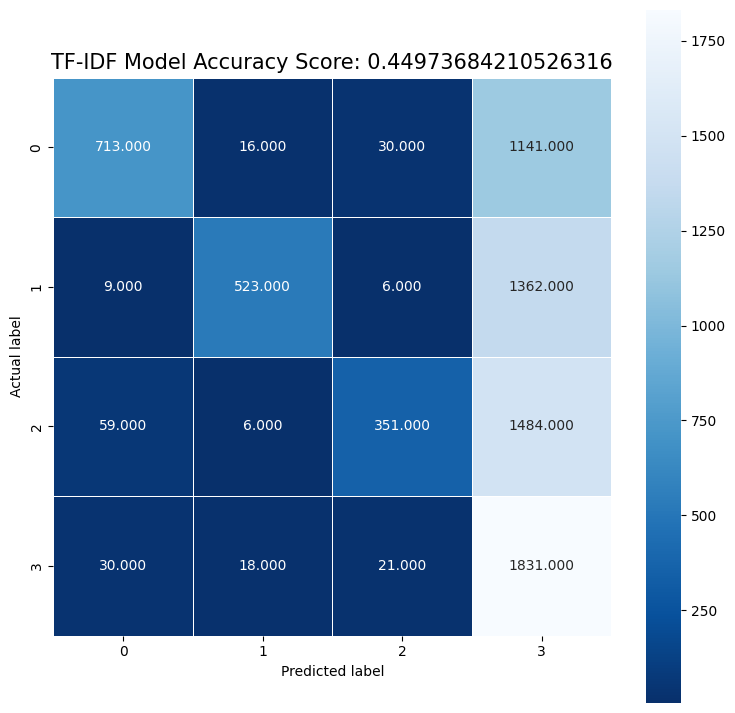

In [86]:
conf_matrix = confusion_matrix(y_val, y_pred_tfidf)
acc = tfidf_model.score(X_val_tfidf, y_val)
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'TF-IDF Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

## Method 3: Using embeddings as features for a model
Thus far we have seen traditional feature extraction methods but with the rise of generative AI design solutions there has been a rise in using text embeddings for many NLP solutions. We will see how the use of embedding features with no other change in model affects the results. 


In [87]:
%%time
# Using sentence-transformers to get embeddings for the tweets
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings_train = model.encode(train_df['text_clean'].tolist(), show_progress_bar=True)
embeddings_val = model.encode(val_df['text_clean'].tolist(), show_progress_bar=True)

embedding_log_model = DecisionTreeClassifier(max_depth=10, random_state=42)
embedding_log_model.fit(embeddings_train, y_train)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/3750 [00:00<?, ?it/s]

Batches:   0%|          | 0/238 [00:00<?, ?it/s]

CPU times: user 1min 11s, sys: 17.8 s, total: 1min 29s
Wall time: 1min 58s


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [88]:
print('Train embeddings shape:', getattr(embeddings_train, 'shape', None))
print('Val embeddings shape:', getattr(embeddings_val, 'shape', None))

Train embeddings shape: (120000, 384)
Val embeddings shape: (7600, 384)


In [89]:
%%time
y_pred_embedding = embedding_log_model.predict(embeddings_val)

CPU times: user 2.06 ms, sys: 2.81 ms, total: 4.87 ms
Wall time: 4.26 ms


In [90]:
print('Embedding Validation classification report:')
print(classification_report(y_val, y_pred_embedding))

Embedding Validation classification report:
              precision    recall  f1-score   support

           1       0.73      0.70      0.71      1900
           2       0.82      0.81      0.81      1900
           3       0.64      0.68      0.66      1900
           4       0.67      0.68      0.67      1900

    accuracy                           0.71      7600
   macro avg       0.72      0.71      0.72      7600
weighted avg       0.72      0.71      0.72      7600



Text(0.5, 1.0, 'Embedding Model Accuracy Score: 0.7148684210526316')

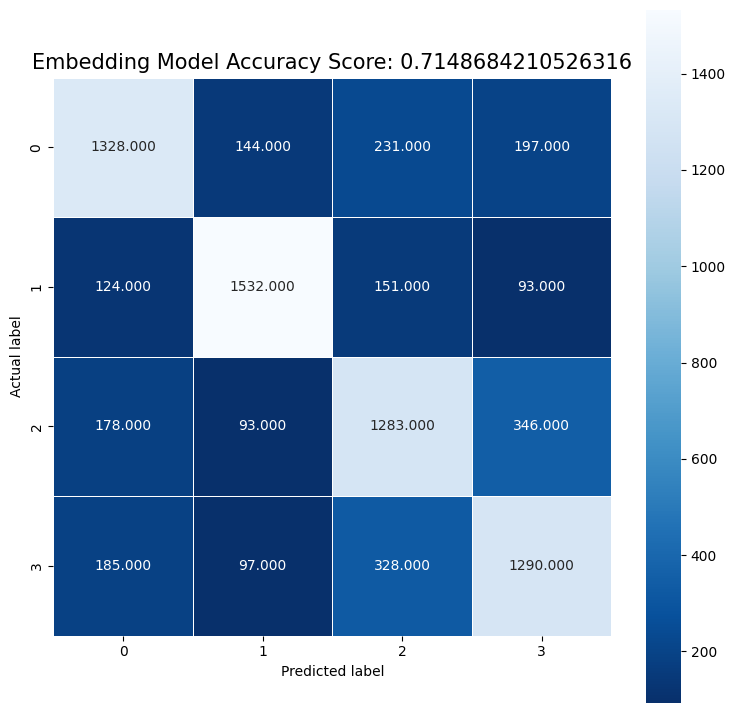

In [91]:
conf_matrix = confusion_matrix(y_val, y_pred_embedding)
acc = embedding_log_model.score(embeddings_val, y_val)
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'Embedding Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

We see a nice improvement here by using text embeddings alone. More complex embedding models may be able to give a classifier even more context and in turn increase the accuracy further. 

## Method 4: Task Specific Model
This will be a somewhat imperfect comparison because we will test an open source model that can classify news into 40 different topics on our data which contains news with 4 topic labels. However this can still give us a good idea of how a task specific model might work on topic classification. 


In [92]:
%%time 
task_specific_model = pipeline("text-classification", model="cssupport/bert-news-class")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

CPU times: user 78.3 ms, sys: 1.64 s, total: 1.72 s
Wall time: 2.44 s


In [93]:
y_pred_task_specific = [task_specific_model(text) for text in val_df['text']]

In [94]:
rows = []
for item in y_pred_task_specific:
    if isinstance(item, list):
        top = item[0] if len(item) > 0 else {}
    elif isinstance(item, dict):
        top = item
    else:
        top = {}
    label = top.get('label') if isinstance(top, dict) else None
    score = top.get('score') if isinstance(top, dict) else None
    rows.append({'label': label, 'score': score})
y_pred_task_specific = pd.DataFrame(rows)
y_pred_task_specific.head()

,label,score
0,LABEL_3,0.795870
1,LABEL_26,0.728585
2,LABEL_3,0.215985
3,LABEL_14,0.616424
4,LABEL_14,0.670967


Some of our categories that the model predicts on are very similar to one another and we can map these to the categories of our labelled data to the best of our ability. 

In [95]:
def remap_label(label):
    label = label.lower()
    #Original "world" label
    world_labels = ["label_7", "label_23", "label_32", "label_39", "label_40"]
    sports_labels = ["label_27"]
    business_labels = ["label_3"]
    sci_tech_labels = ["label_10", "label_26", "label_31"]
    if label in world_labels:
        return 1
    #Original "sports" label
    elif label in sports_labels:
        return 2
    #Original "business" label
    elif label in business_labels:
        return 3
    #Original "sci/tech" label
    elif label in sci_tech_labels:
        return 4
    else:
        return 0

In [96]:
y_pred_remapped = y_pred_task_specific["label"].apply(remap_label)

Text(0.5, 1.0, 'Task Specific Model Accuracy Score: 0.7472368421052632')

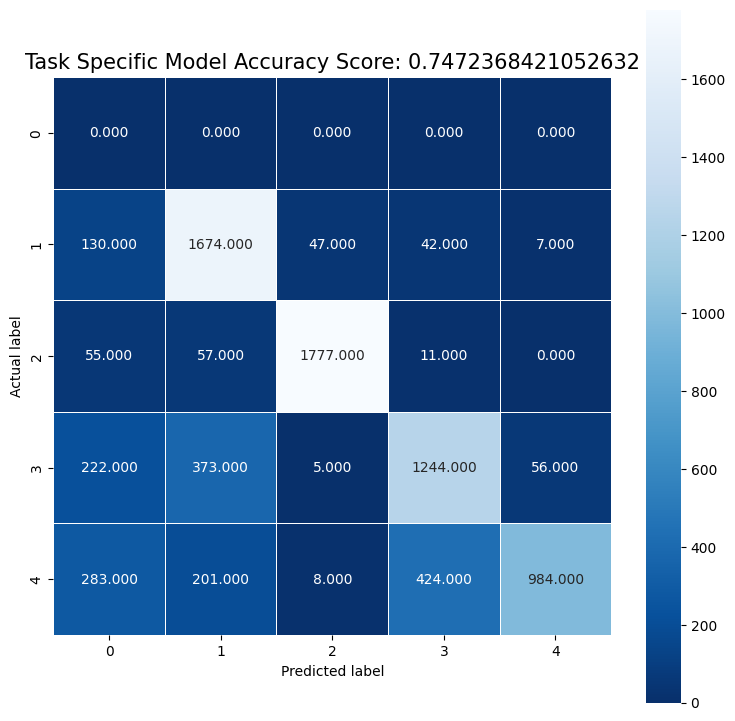

In [97]:
conf_matrix = confusion_matrix(y_val, y_pred_remapped)
acc = accuracy_score(y_val, y_pred_remapped)
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'Task Specific Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

Even with the very imperfect mapping of topics from the 40 possible topics of the model to the 4 topics of the dataset, we see an improvement over the previous models. This is a testament to the power of fine tuning a model to a specific task. 

## Method 5: Hosting a small local general LLM to predict using a prompt

We might want to test the ability of a general model to solve this problem, however, this will take much longer to run in general. To make this more practical, we will take a sample of tweets to run this on. While this does not result in a 1-to-1 comparison, we can compare it's rate of accuracy. Ultimately this is done purely to make running the code more practical.

In [98]:
sampled_articles = val_df.sample(500, random_state=1234)

In [99]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
model.eval()
print("Model loaded!")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk.


Model loaded!


In [100]:
def classify_news(text):
    messages = [
        {"role": "user", "content": f"Classify the topic of this news article with one word based on what it is about, either 'world', 'sports', 'sci/tech', or 'business'.\n\nArticle: {text}"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs, max_new_tokens=5, do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.3,
        )
    new_tokens = output_ids[0][inputs["input_ids"].shape[-1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()
    return 1 if "world" in response else 2 if "sports" in response else 3 if "sci/tech" in response else 4 if "business" in response else 0

In [101]:
y_pred_llm = [classify_news(article) for article in sampled_articles['text']]

In [102]:
y_pred_llm.count(1), y_pred_llm.count(2), y_pred_llm.count(3), y_pred_llm.count(4)

(179, 3, 5, 85)

In the future we could batch requests or find a better prompt that yields more strict and accurate results. 

In [103]:
sampled_articles['label']

2364    4
5047    3
5641    1
1847    3
1566    2
       ..
1981    1
2181    4
5242    2
3962    2
4100    4
Name: label, Length: 500, dtype: int64

In [104]:
y_pred_llm

[1,
 4,
 1,
 4,
 0,
 0,
 0,
 1,
 1,
 1,
 4,
 4,
 1,
 0,
 0,
 1,
 4,
 0,
 1,
 4,
 0,
 4,
 0,
 4,
 1,
 0,
 1,
 1,
 2,
 1,
 1,
 1,
 4,
 4,
 0,
 3,
 1,
 4,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 4,
 4,
 1,
 0,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 4,
 0,
 1,
 4,
 1,
 0,
 0,
 4,
 4,
 1,
 0,
 0,
 1,
 0,
 0,
 4,
 0,
 1,
 0,
 4,
 1,
 1,
 0,
 4,
 1,
 4,
 0,
 4,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 4,
 0,
 1,
 0,
 0,
 4,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 4,
 0,
 4,
 0,
 0,
 1,
 0,
 4,
 3,
 0,
 1,
 4,
 0,
 0,
 0,
 0,
 0,
 1,
 4,
 4,
 2,
 0,
 0,
 0,
 0,
 1,
 4,
 0,
 4,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 4,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 4,
 4,
 1,
 0,
 1,
 1,
 0,
 4,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 4,
 0,
 1,
 0,
 4,
 0,
 0,
 1,
 0,
 1,
 1,
 4,
 4,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 4,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 4,
 1,
 4,
 1,
 0,
 0,
 1,
 0,
 4,
 1,
 1,
 1,
 1,
 1,
 4,
 0,
 0,
 1,
 0,
 1,
 0,
 4,
 0,
 1,
 0,
 4,
 0,
 4,
 0,
 1,
 1,
 1,
 0,
 1,
 0,


Text(0.5, 1.0, 'LLM Topic Accuracy Score: 0.188')

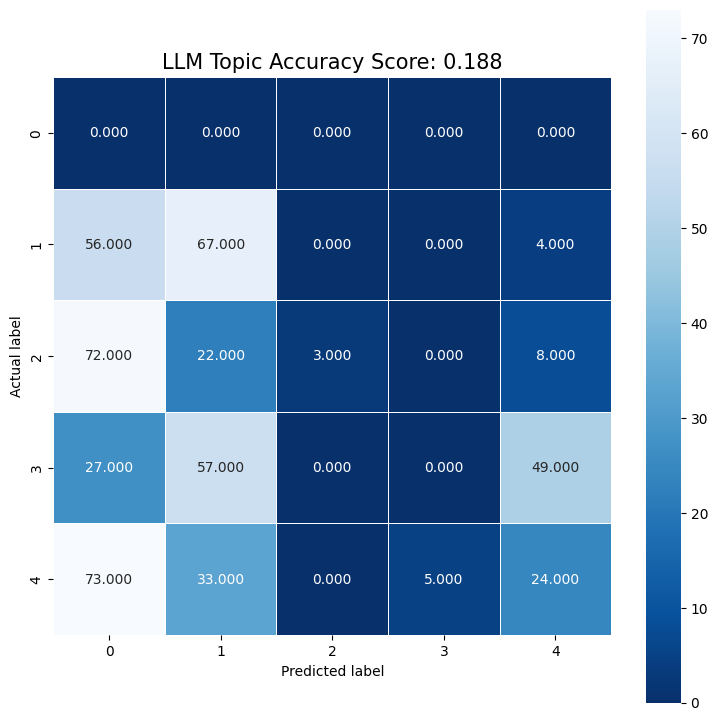

In [105]:
conf_matrix = confusion_matrix(sampled_articles['label'], y_pred_llm)
acc = accuracy_score(sampled_articles['label'], y_pred_llm)
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'LLM Topic Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)